In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../../..")

from gob.benchmarks import *
from gob.optimizers import *
import matplotlib
matplotlib.rcParams.update({"text.usetex": True})

In [2]:
class MinWrapper:
  def __init__(self, func):
    self.func = func
    self.visual_bounds = func.visual_bounds
    self.values = []
  
  def __call__(self, x):
    y = self.func(x)
    self.values.append(y)
    return y
  
  def get_min_per_iteration(self, n_particles):
    mins = []
    for i in range(len(self.values) // n_particles):
      prev_min = mins[-1] if mins else float("inf")
      actual_min = np.min(self.values[i * n_particles : (i + 1) * n_particles])
      mins.append(min(prev_min, actual_min))
    return mins

class MinWrapperGrad:
  def __init__(self, func):
    self.func = func
    self.visual_bounds = func.visual_bounds
    self.values = []
    self.prev_sample = None
  
  def __call__(self, x):
    y = self.func(x)
    if self.prev_sample is None or not np.all(np.abs(x - self.prev_sample) <= 2e-9):
      self.values.append(y)
    self.prev_sample = x
    return y
  
  def get_min_per_iteration(self, n_particles):
    mins = []
    for i in range(len(self.values) // n_particles):
      prev_min = mins[-1] if mins else float("inf")
      actual_min = np.min(self.values[i * n_particles : (i + 1) * n_particles])
      mins.append(min(prev_min, actual_min))
    return mins

In [3]:
g = Ackley()
dim = 4
bounds = augment_dimensions(g.visual_bounds, dim)
n_particles = 50
iter = 400
verbose = False
n_runs = 20
wrapper = MinWrapperGrad
alg = CBO

In [4]:
def format_results(res):
  for i in range(len(res)):
    if len(res[i]) < iter:
      print(f"Run {i} of mins has length {len(res[i])} instead of {iter}")
      # Copy the last value to extend the length
      last_value = res[i][-1]
      res[i] = list(res[i]) + [last_value] * (iter - len(res[i]))

In [ ]:
cn_alg = lambda gamma: SMD_MSGD(bounds=bounds, n_particles=n_particles, iter=iter, moment="MVAR", verbose=verbose, gamma=gamma)
results = []
gammas = np.linspace(1e-5, 2, 50)
for gamma in gammas:
  print(f"Gamma: {gamma}")
  mins = []
  for i in range(n_runs):
    f = wrapper(g)
    opt = cn_alg(gamma)
    res = opt.minimize(f)
    print(f"Results for {opt} on {g}: {res[1]}")
    mins.append(res[1])
  results.append((np.mean(mins), np.std(mins)))

Gamma: 1e-05
Results for SMD-MSGD on Ackley: 19.0524174537139


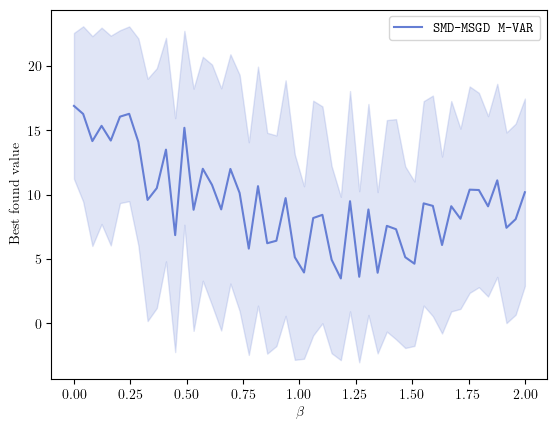

In [ ]:
fig, ax = plt.subplots()
results = np.array(results)
cmap = matplotlib.colormaps["coolwarm"]

c0 = cmap(0)
ax.plot(gammas, results[:, 0], color="#657ed4", label=r"\texttt{SMD-MSGD M-VAR}")
ax.fill_between(gammas, results[:, 0] - results[:, 1], results[:, 0] + results[:, 1], color="#657ed4", alpha=0.2)
ax.legend()
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\textrm{Best found value}$")
plt.savefig("hyperparams_gamma_MSGD.pdf", bbox_inches="tight")

In [ ]:
cn_alg = lambda delta: SMD_MSGD(bounds=bounds, n_particles=n_particles, iter=iter, moment="MVAR", verbose=verbose, delta=delta)
results = []
deltas = np.linspace(2, 5, 50)
for delta in deltas:
  print(f"Delta: {delta}")
  mins = []
  for i in range(n_runs):
    f = wrapper(g)
    opt = cn_alg(delta)
    res = opt.minimize(f)
    print(f"Results for {opt} on {g}: {res[1]}")
    mins.append(res[1])
  results.append((np.mean(mins), np.std(mins)))

Delta: 2.0
Results for SMD-MSGD on Ackley: 0.5840030519488697
Results for SMD-MSGD on Ackley: 0.6397299691930738
Results for SMD-MSGD on Ackley: 0.5146873393755382
Results for SMD-MSGD on Ackley: 0.3642591646899018
Results for SMD-MSGD on Ackley: 17.21896143076166
Results for SMD-MSGD on Ackley: 19.181266688578045
Results for SMD-MSGD on Ackley: 0.7605915828083281
Results for SMD-MSGD on Ackley: 19.10975634352714
Results for SMD-MSGD on Ackley: 0.3801294382614171
Results for SMD-MSGD on Ackley: 0.5890279775496734
Results for SMD-MSGD on Ackley: 0.733420407230867
Results for SMD-MSGD on Ackley: 18.846242166321282
Results for SMD-MSGD on Ackley: 0.3209836708477245
Results for SMD-MSGD on Ackley: 18.860781009330783
Results for SMD-MSGD on Ackley: 19.477023023177
Results for SMD-MSGD on Ackley: 19.73053916352781
Results for SMD-MSGD on Ackley: 0.6979548548131871
Results for SMD-MSGD on Ackley: 18.329039189689095
Results for SMD-MSGD on Ackley: 0.4245915066633157
Results for SMD-MSGD on Ack

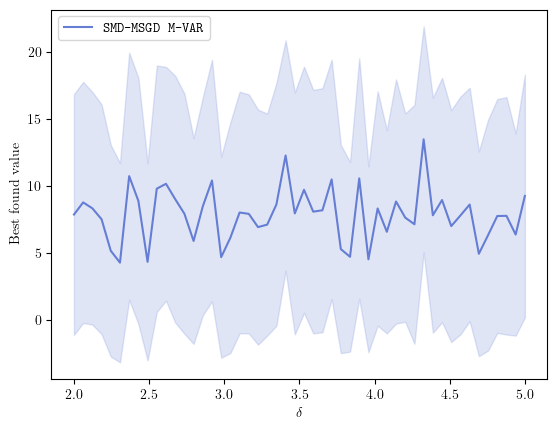

In [ ]:
fig, ax = plt.subplots()
results = np.array(results)
cmap = matplotlib.colormaps["coolwarm"]

c0 = cmap(0)
ax.plot(deltas, results[:, 0], color="#657ed4", label=r"\texttt{SMD-MSGD M-VAR}")
ax.fill_between(deltas, results[:, 0] - results[:, 1], results[:, 0] + results[:, 1], color="#657ed4", alpha=0.2)
ax.legend()
ax.set_xlabel(r"$\delta$")
ax.set_ylabel(r"$\textrm{Best found value}$")
plt.savefig("hyperparams_delta_MSGD.pdf", bbox_inches="tight")

In [5]:
cn_alg = lambda gamma: SMD_Langevin(bounds=bounds, n_particles=n_particles, iter=iter, moment="MVAR", verbose=verbose, gamma=gamma)
results = []
gammas = np.linspace(1e-5, 2, 50)
for gamma in gammas:
  print(f"Gamma: {gamma}")
  mins = []
  for i in range(n_runs):
    f = wrapper(g)
    opt = cn_alg(gamma)
    res = opt.minimize(f)
    print(f"Results for {opt} on {g}: {res[1]}")
    mins.append(res[1])
  results.append((np.mean(mins), np.std(mins)))

Gamma: 1e-05
Results for SMD-Langevin on Ackley: 19.73893018036448
Results for SMD-Langevin on Ackley: 0.5436776118321842
Results for SMD-Langevin on Ackley: 0.7062225590187734
Results for SMD-Langevin on Ackley: 19.73396585366988
Results for SMD-Langevin on Ackley: 0.6059988759333312
Results for SMD-Langevin on Ackley: 0.45585058385159316
Results for SMD-Langevin on Ackley: 19.15522002656249
Results for SMD-Langevin on Ackley: 17.617872171427344
Results for SMD-Langevin on Ackley: 17.38591294238452
Results for SMD-Langevin on Ackley: 19.298850703485243
Results for SMD-Langevin on Ackley: 18.790152015493188
Results for SMD-Langevin on Ackley: 17.963349652169285
Results for SMD-Langevin on Ackley: 0.4519642574243403
Results for SMD-Langevin on Ackley: 0.4138618673943637
Results for SMD-Langevin on Ackley: 0.6333659180321267
Results for SMD-Langevin on Ackley: 0.3610464330937089
Results for SMD-Langevin on Ackley: 0.4420598113966254
Results for SMD-Langevin on Ackley: 1.2080393478189326


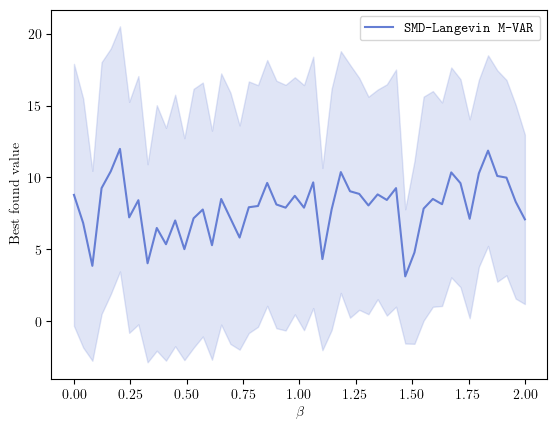

In [6]:
fig, ax = plt.subplots()
results = np.array(results)
cmap = matplotlib.colormaps["coolwarm"]

c0 = cmap(0)
ax.plot(gammas, results[:, 0], color="#657ed4", label=r"\texttt{SMD-Langevin M-VAR}")
ax.fill_between(gammas, results[:, 0] - results[:, 1], results[:, 0] + results[:, 1], color="#657ed4", alpha=0.2)
ax.legend()
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\textrm{Best found value}$")
plt.savefig("hyperparams_gamma_Langevin.pdf", bbox_inches="tight")

In [7]:
cn_alg = lambda delta: SMD_Langevin(bounds=bounds, n_particles=n_particles, iter=iter, moment="MVAR", verbose=verbose, delta=delta)
results = []
deltas = np.linspace(2, 5, 50)
for delta in deltas:
  print(f"Delta: {delta}")
  mins = []
  for i in range(n_runs):
    f = wrapper(g)
    opt = cn_alg(delta)
    res = opt.minimize(f)
    print(f"Results for {opt} on {g}: {res[1]}")
    mins.append(res[1])
  results.append((np.mean(mins), np.std(mins)))

Delta: 2.0
Results for SMD-Langevin on Ackley: 0.7922789692768188
Results for SMD-Langevin on Ackley: 0.844658231716537
Results for SMD-Langevin on Ackley: 2.3096983317421302
Results for SMD-Langevin on Ackley: 0.746040190266346
Results for SMD-Langevin on Ackley: 18.077504219391116
Results for SMD-Langevin on Ackley: 0.548557611349477
Results for SMD-Langevin on Ackley: 2.4011360060269245
Results for SMD-Langevin on Ackley: 1.1798283908563083
Results for SMD-Langevin on Ackley: 0.8181570683972272
Results for SMD-Langevin on Ackley: 19.178728772993285
Results for SMD-Langevin on Ackley: 3.0681176686688727
Results for SMD-Langevin on Ackley: 18.405824885110444
Results for SMD-Langevin on Ackley: 4.604026187586918
Results for SMD-Langevin on Ackley: 1.3435064084993624
Results for SMD-Langevin on Ackley: 19.335175464494398
Results for SMD-Langevin on Ackley: 13.723167656789768
Results for SMD-Langevin on Ackley: 1.767999648921983
Results for SMD-Langevin on Ackley: 1.2545708201436772
Resu

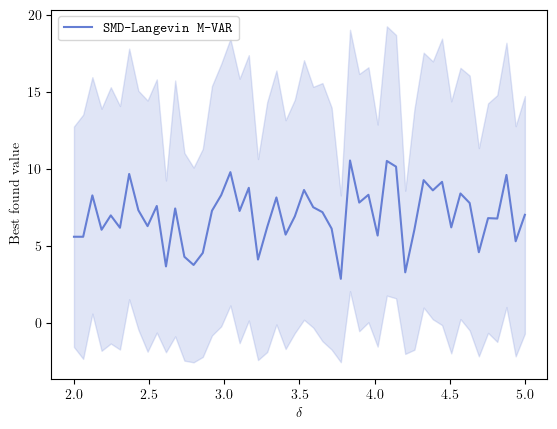

In [8]:
fig, ax = plt.subplots()
results = np.array(results)
cmap = matplotlib.colormaps["coolwarm"]

c0 = cmap(0)
ax.plot(deltas, results[:, 0], color="#657ed4", label=r"\texttt{SMD-Langevin M-VAR}")
ax.fill_between(deltas, results[:, 0] - results[:, 1], results[:, 0] + results[:, 1], color="#657ed4", alpha=0.2)
ax.legend()
ax.set_xlabel(r"$\delta$")
ax.set_ylabel(r"$\textrm{Best found value}$")
plt.savefig("hyperparams_delta_Langevin.pdf", bbox_inches="tight")